In [1]:
# THIRD PARTY
import astropy.coordinates as coord
import astropy.units as u
from astropy.visualization import quantity_support, time_support

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import InterpolatedUnivariateSpline as IUS

# PROJECT-SPECIFIC
import trackstream
from trackstream import StreamTrack


quantity_support()
time_support()

set autoreload to 1


<astropy.visualization.time.time_support.<locals>.MplTimeConverter at 0x7fb2dec11550>

In [2]:
class InterpolatedUnivariateSplinewithUnits(IUS):
    
    def __init__(self, x, y, w=None, x_unit=None, y_unit=None,
                 bbox=[None, None], k=3, ext=0, check_finite=False):
        self._xunit = x_unit or x.unit
        self._yunit = y_unit or y.unit
        
        x = x.to_value(x_unit)
        y = y.to_value(y_unit)
        
        super().__init__(x, y, w=w, bbox=bbox, k=k, ext=ext, check_finite=check_finite)
    
    def __call__(self, x, nu=0, ext=None):
        x = x.to_value(self._xunit)
        y = super().__call__(x, nu=nu, ext=ext)
        
        return y * self._yunit
    
IUSU = InterpolatedUnivariateSplinewithUnits

In [3]:
num = 40

arclength = np.linspace(0, 10, num=num) * u.deg

data = coord.ICRS(
    coord.SphericalRepresentation(
        lon=np.linspace(0, 180, num=num) * u.deg,
        lat=np.linspace(-45, 45, num=num) * u.deg,
        distance=np.linspace(2, 25, num=num) * u.kpc,
        # pm_ra_cosdec
    )
)

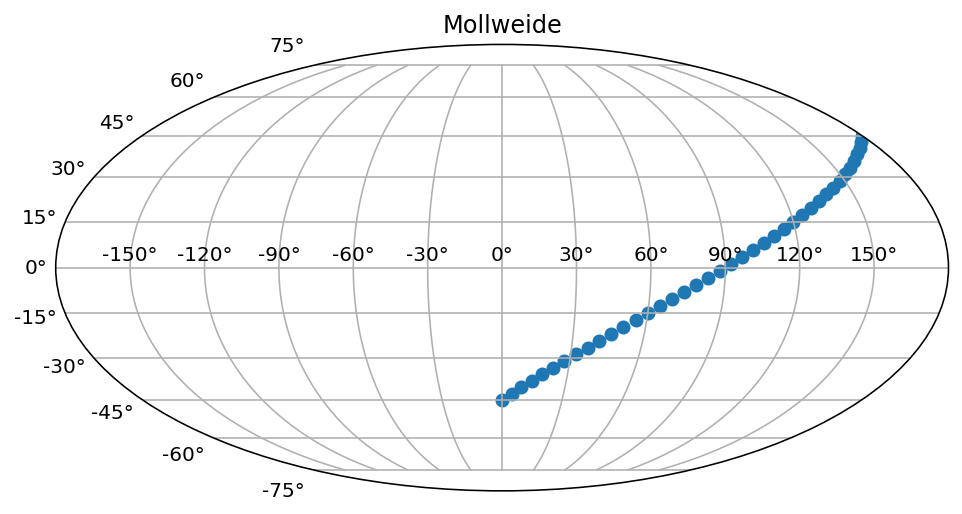

In [4]:
plt.figure(figsize=(8, 8))
plt.subplot(111, projection="mollweide")
plt.title("Mollweide")
plt.grid(True)

plt.scatter(data.ra.to_value(u.rad), data.dec.to_value(u.rad))

plt.show();

In [5]:
interpolations = dict(
    lon=IUSU(arclength, data.ra),
    lat=IUSU(arclength, data.dec),
    distance=IUSU(arclength, data.distance)
)

In [6]:
track = StreamTrack(
    data=data, interpolations=interpolations
)

In [9]:
track(np.linspace(1, 5, num=num) * u.deg)

<ICRS Coordinate: (ra, dec, distance) in (deg, deg, kpc)
    [(18.        , -3.60000000e+01,  4.3       ),
     (19.84615385, -3.50769231e+01,  4.53589744),
     (21.69230769, -3.41538462e+01,  4.77179487),
     (23.53846154, -3.32307692e+01,  5.00769231),
     (25.38461538, -3.23076923e+01,  5.24358974),
     (27.23076923, -3.13846154e+01,  5.47948718),
     (29.07692308, -3.04615385e+01,  5.71538462),
     (30.92307692, -2.95384615e+01,  5.95128205),
     (32.76923077, -2.86153846e+01,  6.18717949),
     (34.61538462, -2.76923077e+01,  6.42307692),
     (36.46153846, -2.67692308e+01,  6.65897436),
     (38.30769231, -2.58461538e+01,  6.89487179),
     (40.15384615, -2.49230769e+01,  7.13076923),
     (42.        , -2.40000000e+01,  7.36666667),
     (43.84615385, -2.30769231e+01,  7.6025641 ),
     (45.69230769, -2.21538462e+01,  7.83846154),
     (47.53846154, -2.12307692e+01,  8.07435897),
     (49.38461538, -2.03076923e+01,  8.31025641),
     (51.23076923, -1.93846154e+01,  8.5461